# Linear Regression 
### A hands-on, interactive walkthrough for beginners

In this notebook you will **build linear regression yourself** — no `sklearn` model doing the
heavy lifting — so you actually understand what's happening under the hood.

**You will:**
1. Learn the math behind linear regression, gradient descent, MSE, RMSE and R².
2. Generate a synthetic dataset and save it to CSV.
3. Load the CSV back in (like a real project).
4. Implement a `LinearRegressionScratch` class from first principles.
5. Train it, visualize the fit, and evaluate it.
6. Save the trained model to disk, then reload it and predict on brand-new data.
7. Implement **K-Fold Cross-Validation** from scratch and visualize its impact.




## 🗺️ Table of Contents
1. [The Theory: What is Regression?](#theory)
2. [Generate & Save Data](#generate)
3. [Load the Data Back](#load)
4. [Building Linear Regression From Scratch](#build)
5. [Training & Visualizing the Fit](#train)
6. [Evaluation Metrics: MSE, RMSE, R²](#metrics)
7. [Saving & Reloading the Model](#save)
8. [Predicting on New Data](#predict)
9. [K-Fold Cross-Validation From Scratch](#kfold)
10. [Wrap-up & Next Steps](#wrapup)


<a id="theory"></a>
## 1. The Theory: What is Regression?

**Regression** is the task of predicting a continuous numeric value (e.g. price, temperature,
salary) from one or more input features.

The simplest case, **Simple Linear Regression**, assumes a straight-line relationship between
one input $x$ and the output $y$:

$$\hat{y} = w \cdot x + b$$

Where:
- $\hat{y}$ — the model's **predicted** value
- $w$ — the **weight** (slope): how much $y$ changes per unit of $x$
- $b$ — the **bias** (intercept): the value of $y$ when $x = 0$

### How do we find the *best* $w$ and $b$?

We define a **cost function** (a.k.a. loss function) that measures how wrong our predictions
are. The standard choice is **Mean Squared Error (MSE)**:

$$J(w, b) = \frac{1}{n}\sum_{i=1}^{n}\left(\hat{y}_i - y_i\right)^2$$

We want to find the $w, b$ that **minimize** $J(w, b)$. We do this with an iterative
optimization algorithm called **Gradient Descent**.

### Gradient Descent

At each step, we nudge $w$ and $b$ in the direction that reduces the loss the fastest —
the *negative gradient*:

$$\frac{\partial J}{\partial w} = \frac{2}{n}\sum_{i=1}^{n}\left(\hat{y}_i - y_i\right)x_i
\qquad\qquad
\frac{\partial J}{\partial b} = \frac{2}{n}\sum_{i=1}^{n}\left(\hat{y}_i - y_i\right)$$

Update rules (repeated for many iterations, using a **learning rate** $\alpha$):

$$w \leftarrow w - \alpha \frac{\partial J}{\partial w}
\qquad\qquad
b \leftarrow b - \alpha \frac{\partial J}{\partial b}$$

That's it — that is the *entire* engine behind linear regression training. We'll implement
exactly these three formulas in code below.


> 🧠 **Quick Question 1**
>
> If the learning rate $\alpha$ is set **way too high**, what do you think will happen to the
> loss $J(w,b)$ as training progresses — will it smoothly decrease, or could something go wrong?
> *(Write down your guess before continuing — we'll revisit this in Section 4.)*


<a id="generate"></a>
## 2. Setup & Generate Synthetic Data

We'll first import the libraries we need, then generate a synthetic dataset with a **known**
true relationship ($y = 3.5x + 7 + \text{noise}$) so we can later check whether our model
recovers something close to those true values.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

os.makedirs('data', exist_ok=True)
os.makedirs('models', exist_ok=True)

print("Libraries loaded. Ready to go!")

Libraries loaded. Ready to go!


In [2]:
# --- Generate synthetic data ---
TRUE_WEIGHT = 3.5
TRUE_BIAS = 7.0
N_SAMPLES = 200
NOISE_STD = 2.0

X = np.random.uniform(0, 10, N_SAMPLES)
noise = np.random.normal(0, NOISE_STD, N_SAMPLES)
y = TRUE_WEIGHT * X + TRUE_BIAS + noise

df = pd.DataFrame({'X': X, 'y': y})
df.head()

,X,y
0,3.745401,18.748855
1,9.507143,40.739508
2,7.319939,33.205933
3,5.986585,26.524344
4,1.560186,16.192201


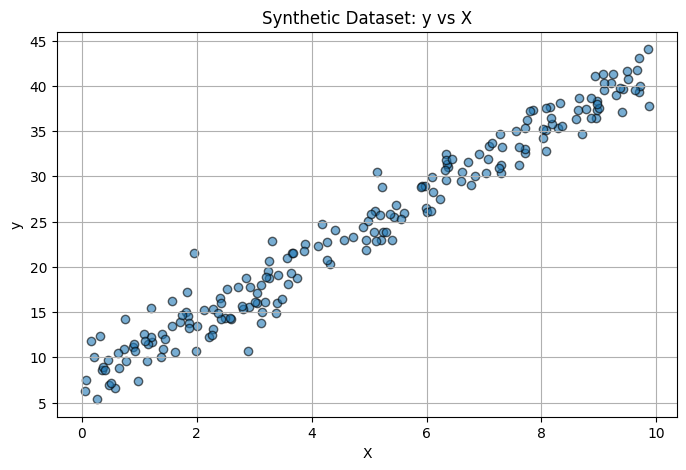

We generated 200 points from the hidden relationship y = 3.5·X + 7.0 + noise
In real life we never know the true relationship — our model has to discover it!


In [3]:
# Visualize the raw data
plt.scatter(df['X'], df['y'], alpha=0.6, edgecolor='k')
plt.title('Synthetic Dataset: y vs X')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

print(f"We generated {N_SAMPLES} points from the hidden relationship "
      f"y = {TRUE_WEIGHT}·X + {TRUE_BIAS} + noise")
print("In real life we never know the true relationship — our model has to discover it!")

In [4]:
# Save the dataset to CSV, just like a real project would
csv_path = 'data/regression_data.csv'
df.to_csv(csv_path, index=False)
print(f"Saved {len(df)} rows to '{csv_path}'")

Saved 200 rows to 'data/regression_data.csv'


<a id="load"></a>
## 3. Load the Data Back In

In a real workflow, training usually happens in a *separate* step/script from data generation.
We simulate that here by reading the CSV back from disk, as if starting fresh.


In [5]:
df_loaded = pd.read_csv('data/regression_data.csv')
print(df_loaded.shape)
df_loaded.describe()

(200, 2)


,X,y
count,200.000000,200.000000
mean,4.840062,24.075047
std,2.948914,10.456237
min,0.055221,5.367902
25%,2.285824,14.833001
50%,4.944863,23.151652
75%,7.568596,33.217525
max,9.868869,44.053096


In [6]:
X = df_loaded['X'].values
y = df_loaded['y'].values

def train_test_split_manual(X, y, test_size=0.2, seed=42):
    """A minimal train/test splitter, built from scratch (no sklearn)."""
    rng = np.random.RandomState(seed)
    idx = rng.permutation(len(X))
    split_point = int(len(X) * (1 - test_size))
    train_idx, test_idx = idx[:split_point], idx[split_point:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

X_train, X_test, y_train, y_test = train_test_split_manual(X, y, test_size=0.2)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 160, Test size: 40


> 🧠 **Quick Question 2**
>
> Why do we split the data into a **train** set and a **test** set instead of training on
> everything? What could go wrong if we evaluated our model only on the same data it was
> trained on?


<a id="build"></a>
## 4. Building Linear Regression From Scratch

We'll implement a small class, `LinearRegressionScratch`, that mirrors the interface of
`sklearn` (`.fit()` / `.predict()`) but is built entirely from the formulas above.

**One practical trick**: we standardize $X$ before running gradient descent
(subtract the mean, divide by the standard deviation). This keeps the gradients well-scaled so
training converges quickly and reliably — then we convert the learned weight/bias back to the
original scale so `.predict()` works on raw, un-scaled inputs.


In [ ]:
class LinearRegressionScratch:
    """Simple linear regression trained with batch gradient descent, built from scratch."""

    def __init__(self, learning_rate=0.1, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.loss_history = []
        self.weight = None
        self.bias = None

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        # Standardize X for stable gradient descent
        self.X_mean = X.mean()
        self.X_std = X.std()
        X_norm = (X - self.X_mean) / self.X_std

        n = len(X_norm)
        w, b = 0.0, 0.0
        self.loss_history = []

        for i in range(self.n_iterations):
            y_pred = w * X_norm + b
            error = y_pred - y

            # MSE loss, for tracking
            loss = np.mean(error ** 2)
            self.loss_history.append(loss)

            # Gradients (see formulas above)
            dw = (2 / n) * np.sum(error * X_norm)
            db = (2 / n) * np.sum(error)

            # Gradient descent update
            w -= self.lr * dw
            b -= self.lr * db

        # Convert w, b back from normalized scale to the original X scale:
        #   y = w * (X - mean)/std + b  =  (w/std)*X + (b - w*mean/std)
        self.weight = w / self.X_std
        self.bias = b - w * self.X_mean / self.X_std
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return self.weight * X + self.bias

    def __repr__(self):
        return f"LinearRegressionScratch(weight={self.weight:.4f}, bias={self.bias:.4f})"

<a id="train"></a>
## 5. Training & Visualizing the Fit

Let's train our model on `X_train`, `y_train` and watch the loss curve fall as gradient descent
does its work.


In [ ]:
model = LinearRegressionScratch(learning_rate=0.5, n_iterations=500)
model.fit(X_train, y_train)

print(model)
print(f"True relationship was:   y = {TRUE_WEIGHT}·X + {TRUE_BIAS}")
print(f"Model learned:           y = {model.weight:.3f}·X + {model.bias:.3f}")

In [ ]:
# Loss curve: does training converge?
plt.plot(model.loss_history, color='crimson')
plt.title('Training Loss (MSE) over Iterations')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.show()

In [ ]:
# Visualize the fitted line against train/test data
x_line = np.linspace(X.min(), X.max(), 100)
y_line = model.predict(x_line)

plt.scatter(X_train, y_train, alpha=0.5, label='Train data', color='steelblue')
plt.scatter(X_test, y_test, alpha=0.7, label='Test data', color='darkorange')
plt.plot(x_line, y_line, color='black', linewidth=2, label='Fitted line')
plt.title('Linear Regression Fit')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

> 🧠 **Quick Question 3**
>
> Try changing `learning_rate` above to something large, like `5.0`, and re-run the training
> and loss-curve cells. What happens to the loss curve? Does this match your prediction from
> Quick Question 1?


<a id="metrics"></a>
## 6. Evaluation Metrics: MSE, RMSE, R²

Now that we have a trained model, how do we know if it's actually *good*? We use three
standard regression metrics.

### Mean Squared Error (MSE)
Average of the squared differences between predictions and true values. Squaring penalizes
large errors more heavily, and keeps everything positive.

$$MSE = \frac{1}{n}\sum_{i=1}^{n}\left(y_i - \hat{y}_i\right)^2$$

### Root Mean Squared Error (RMSE)
The square root of MSE. This brings the error back into the **same units as $y$**, which makes
it much easier to interpret (e.g. "on average we're off by 2.1 units").

$$RMSE = \sqrt{MSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}\left(y_i - \hat{y}_i\right)^2}$$

### R² (Coefficient of Determination)
Measures the proportion of variance in $y$ that is explained by the model, relative to a naive
baseline that always predicts the mean $\bar{y}$. $R^2 = 1$ is a perfect fit, $R^2 = 0$ means
the model is no better than predicting the mean, and $R^2$ can go negative for a very bad model.

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}$$


In [ ]:
def mse(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return np.mean((y_true - y_pred) ** 2)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

def r2_score(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

In [ ]:
y_test_pred = model.predict(X_test)

print(f"MSE  : {mse(y_test, y_test_pred):.4f}")
print(f"RMSE : {rmse(y_test, y_test_pred):.4f}")
print(f"R^2  : {r2_score(y_test, y_test_pred):.4f}")

In [ ]:
# Residual plot: are errors randomly scattered around 0? (a good sign) or patterned? (a bad sign)
residuals = y_test - y_test_pred

plt.scatter(X_test, residuals, alpha=0.7, color='seagreen')
plt.axhline(0, color='black', linestyle='--')
plt.title('Residual Plot (Test Set)')
plt.xlabel('X')
plt.ylabel('Residual (y_true - y_pred)')
plt.show()

> 🧠 **Quick Question 4**
>
> RMSE and MSE are always ≥ 0, where lower is better. R² usually ranges from 0 to 1, where
> higher is better. If someone reports **R² = 0.98**, is that automatically a great model? What
> else would you want to know before trusting that number? *(Hint: think about what R² does and
> doesn't measure — e.g. outliers, overfitting, causation.)*


<a id="save"></a>
## 7. Saving the Trained Model

Training is expensive (relatively speaking); we don't want to retrain from scratch every time
we want a prediction. We'll **serialize** the trained model object with Python's built-in
`pickle` module and save it to disk.


In [ ]:
model_path = 'models/linear_regression_scratch.pkl'

with open(model_path, 'wb') as f:
    pickle.dump(model, f)

print(f"Model saved to '{model_path}'")

<a id="predict"></a>
## 8. Reloading the Model & Predicting on New Data

Now let's simulate a completely separate session: we reload the model from disk (no access to
the original `model` variable/training code) and use it to predict on **brand-new** data points.


In [ ]:
with open(model_path, 'rb') as f:
    loaded_model = pickle.load(f)

print("Reloaded model:", loaded_model)

In [ ]:
# Generate brand-new "unseen" data (e.g. from a future batch / a different source)
new_X = np.random.uniform(0, 10, 15)
new_predictions = loaded_model.predict(new_X)

new_df = pd.DataFrame({'X': new_X, 'predicted_y': new_predictions})
new_df.sort_values('X').reset_index(drop=True)

In [ ]:
# Visualize new predictions against the original fitted line
plt.scatter(X, y, alpha=0.25, color='gray', label='Original training data')
plt.plot(x_line, y_line, color='black', linewidth=2, label='Fitted line')
plt.scatter(new_X, new_predictions, color='red', edgecolor='k', s=80,
            label='New predictions', zorder=5)
plt.title('Predictions on New, Unseen Data')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

<a id="kfold"></a>
## 9. K-Fold Cross-Validation From Scratch

So far we've evaluated our model on **one** train/test split. But what if that particular split
was unusually easy (or hard)? Our metric could be misleadingly optimistic or pessimistic.

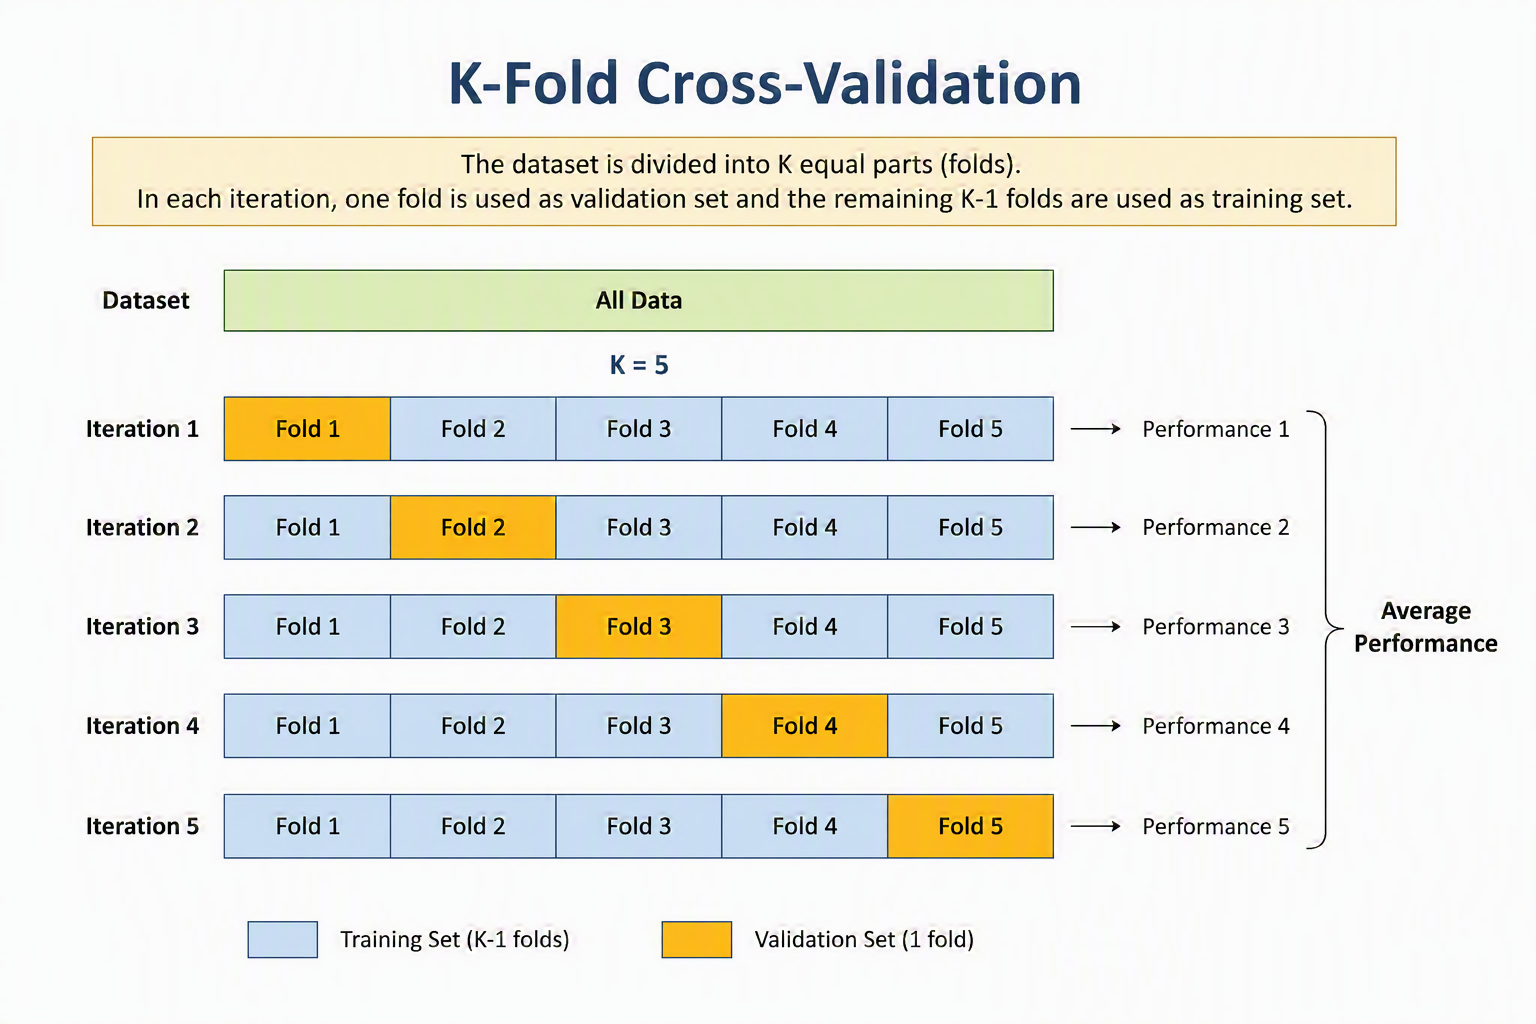

**K-Fold Cross-Validation** solves this by:
1. Splitting the data into $k$ roughly equal "folds".
2. For each fold $i$: train on the other $k-1$ folds, test on fold $i$.
3. Averaging the metric across all $k$ runs.

This gives a much more **robust estimate** of how well the model generalizes, and also tells us
how much that estimate **varies** depending on which data it sees.

$$\text{CV Score} = \frac{1}{k}\sum_{i=1}^{k} \text{metric}(y_{\text{fold}_i}, \hat{y}_{\text{fold}_i})$$


In [ ]:
def k_fold_split(n_samples, k=5, seed=42):
    """Return a list of k arrays of indices, each representing one fold."""
    rng = np.random.RandomState(seed)
    indices = rng.permutation(n_samples)

    fold_sizes = np.full(k, n_samples // k, dtype=int)
    fold_sizes[: n_samples % k] += 1  # distribute the remainder

    folds = []
    current = 0
    for size in fold_sizes:
        folds.append(indices[current: current + size])
        current += size
    return folds

K = 5
folds = k_fold_split(len(X), k=K)
for i, f in enumerate(folds):
    print(f"Fold {i}: {len(f)} samples")

In [ ]:
# Visualize which points fall in which fold
plt.figure(figsize=(9, 5))
colors = plt.cm.tab10(np.linspace(0, 1, K))
for i, fold_idx in enumerate(folds):
    plt.scatter(X[fold_idx], y[fold_idx], color=colors[i], label=f'Fold {i}', alpha=0.7)
plt.title('K-Fold Split Visualization (each color = one fold)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

In [ ]:
fold_r2, fold_mse, fold_rmse = [], [], []

for i in range(K):
    test_idx = folds[i]
    train_idx = np.hstack([folds[j] for j in range(K) if j != i])

    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    fold_model = LinearRegressionScratch(learning_rate=0.5, n_iterations=500)
    fold_model.fit(X_tr, y_tr)
    preds = fold_model.predict(X_te)

    fold_r2.append(r2_score(y_te, preds))
    fold_mse.append(mse(y_te, preds))
    fold_rmse.append(rmse(y_te, preds))

    print(f"Fold {i}:  R2={fold_r2[-1]:.4f}   MSE={fold_mse[-1]:.4f}   RMSE={fold_rmse[-1]:.4f}")

print("\n--- Cross-Validation Summary ---")
print(f"Mean R2   : {np.mean(fold_r2):.4f}  (+/- {np.std(fold_r2):.4f})")
print(f"Mean MSE  : {np.mean(fold_mse):.4f}  (+/- {np.std(fold_mse):.4f})")
print(f"Mean RMSE : {np.mean(fold_rmse):.4f}  (+/- {np.std(fold_rmse):.4f})")

In [ ]:
# Visualize the impact: how much does the score vary fold to fold?
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(range(K), fold_r2, color='mediumseagreen', edgecolor='k')
axes[0].axhline(np.mean(fold_r2), color='red', linestyle='--', label=f'Mean = {np.mean(fold_r2):.3f}')
axes[0].set_title('R² per Fold')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('R²')
axes[0].legend()

axes[1].boxplot([fold_mse, fold_rmse], tick_labels=['MSE', 'RMSE'])
axes[1].set_title('Spread of Error Metrics Across Folds')

plt.tight_layout()
plt.show()

**Why this matters:** if the bars/box above were wildly different in height, that would
warn us that our single train/test split earlier could have given a misleading picture of model
performance. Averaging across folds (and looking at the *spread*, not just the mean) gives a
much more trustworthy estimate — this is why K-Fold CV is standard practice before trusting a
model.


> 🧠 **Quick Question 5**
>
> What would happen to the number of folds, the size of each fold, and the total training time
> if you set $k$ equal to the number of samples $n$ (this special case is called
> **Leave-One-Out Cross-Validation**, or LOOCV)? What's a downside of using a very large $k$?

> 🧠 **Quick Question 6 (try it!)**
>
> Change `K = 5` to `K = 3` and then `K = 10` in the cell above and re-run. How does the mean
> R² change? How does the *variance* (spread) of the scores change? Is more folds always better?


<a id="wrapup"></a>
## 10. Wrap-up & Next Steps

**What we covered:**
- The math of linear regression: $\hat{y} = wx + b$, the MSE cost function, and gradient
  descent update rules.
- Generating, saving, and reloading a dataset via CSV.
- Implementing linear regression **from scratch** with no ML libraries.
- Evaluating with MSE, RMSE, and R², and reading a residual plot.
- Saving a trained model with `pickle` and reloading it to predict on new data — just like a
  real deployed model would.
- Implementing **K-Fold Cross-Validation** from scratch, visualizing the folds, and seeing how
  it reveals the variability in model performance.

**Ideas to extend this notebook yourself:**
1. Add a **second feature** and extend `LinearRegressionScratch` to multiple linear regression
   (hint: replace the single weight with a weight vector, use matrix operations).
2. Add **L2 regularization** (Ridge Regression) to the cost function and see how it affects the
   weights and cross-validation variance.
3. Compare your from-scratch model's results to `sklearn.linear_model.LinearRegression` on the
   same data — do you get the same $w$ and $b$?
4. Try a dataset with a **non-linear** relationship (e.g. $y = x^2$) and see how badly a linear
   model fits — this motivates polynomial or non-linear regression.


